In [92]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

In [93]:
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2, n_classes=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [94]:
class LogisticRegression:
    def __init__(self):
        self.epochs = 1000
        self.learning_rate = 0.01
        self.weights = None
        self.bias = None

    def sigmoid(self, x):
        # 1 / 1 + e^-x
        return 1/(1 + np.exp(-x))    
    
    def fit(self, X, y):
        n_instances, n_columns = X.shape
        self.weights = np.zeros(n_columns)
        self.bias = 0


        for _ in range(self.epochs):
            model = np.dot(X, self.weights) + self.bias
            y_predict = self.sigmoid(model)

            error = y_predict - y
            weight_derivative = (1 / n_instances) * np.dot(X.T, (error))
            bias_derivative = (1 / n_instances) * np.sum(error)

            self.weights -= self.learning_rate * weight_derivative
            self.bias -= self.learning_rate * bias_derivative

    def predict(self, X):
        model = np.dot(X , self.weights) + self.bias
        proba = self.sigmoid(model)
        return np.where(proba >= 0.5, 1, 0)


In [95]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.92


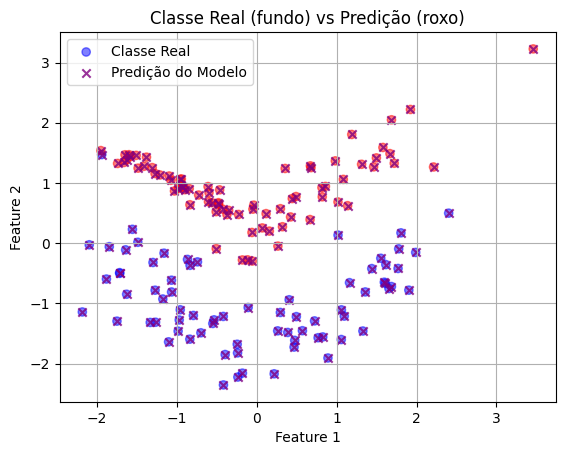

In [96]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', label='Classe Real', alpha=0.5)

plt.scatter(X_test[:, 0], X_test[:, 1], c='purple', marker='x', label='Predição do Modelo', alpha=0.8)

plt.title('Classe Real (fundo) vs Predição (roxo)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()
#Lembrar que classe 0 é azul e 1 é vermelho

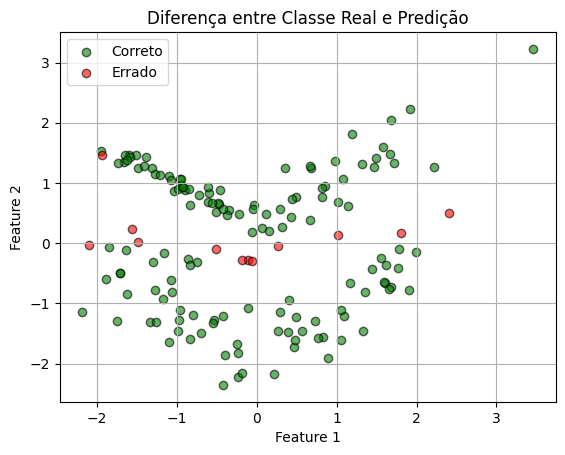

In [97]:
acertos = y_pred == y_test

plt.scatter(X_test[acertos, 0], X_test[acertos, 1], c='green', label='Correto', alpha=0.6, edgecolor='k')
plt.scatter(X_test[~acertos, 0], X_test[~acertos, 1], c='red', label='Errado', alpha=0.6, edgecolor='k')

plt.title('Diferença entre Classe Real e Predição')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()